# **1. Importar librerías**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# **2. Cargar el Dataset**

In [2]:
# Cargar dataset
cancer = load_breast_cancer()

# Convertir a DataFrame para mejor visualización
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras 5 filas:")
display(df.head())

print("\nDistribución de clases:")
print(df['target'].value_counts())
print("\n0 = Maligno | 1 = Benigno")

Dimensiones del dataset: (569, 31)

Primeras 5 filas:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64

0 = Maligno | 1 = Benigno


# **3. Preparación de los datos**

In [3]:
X = cancer.data
y = cancer.target

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=42,
                                                    stratify=y)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

Train: 426 muestras
Test: 143 muestras


# **4. Entrenar el modelo de Regresión Logística**

In [4]:
# Crear y entrenar el modelo
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **5. Predicciones y Matriz de Confusión**

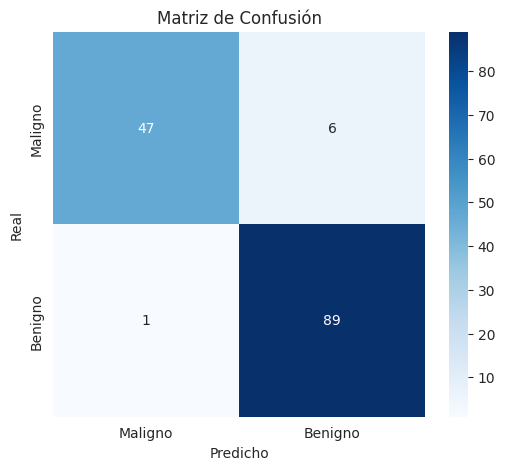

              precision    recall  f1-score   support

     Maligno       0.98      0.89      0.93        53
     Benigno       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



In [5]:
# Predicciones
y_pred = model.predict(X_test)

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# Reporte de clasificación
print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

# **6. Métricas de Evaluación**

In [6]:
# AUC-ROC
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC-ROC: {auc:.4f}")

AUC-ROC: 0.9956


# **7. Cross Validation**

In [7]:
# K-Fold Cross Validation
cv5 = cross_val_score(model, X, y, cv=5, scoring='accuracy')
cv10 = cross_val_score(model, X, y, cv=10, scoring='accuracy')

print(f"Accuracy CV-5  → Media: {cv5.mean():.4f} ± {cv5.std():.4f}")
print(f"Accuracy CV-10 → Media: {cv10.mean():.4f} ± {cv10.std():.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Accuracy CV-5  → Media: 0.9526 ± 0.0142
Accuracy CV-10 → Media: 0.9508 ± 0.0219


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# **8. Optimización de Hiperparámetros**

In [8]:
# GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000),
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy:", grid_search.best_score_)

Mejores parámetros: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Mejor accuracy: 0.9576744186046513


# **9. Ajuste del Umbral de Decisión**

In [9]:
# Predicciones con probabilidad
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Probar diferentes umbrales
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    print(f"\nUmbral = {thresh}")
    print(classification_report(y_test, y_pred_thresh, target_names=['Maligno', 'Benigno'], zero_division=0))


Umbral = 0.3
              precision    recall  f1-score   support

     Maligno       1.00      0.87      0.93        53
     Benigno       0.93      1.00      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.95       143
weighted avg       0.95      0.95      0.95       143


Umbral = 0.4
              precision    recall  f1-score   support

     Maligno       0.98      0.89      0.93        53
     Benigno       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143


Umbral = 0.5
              precision    recall  f1-score   support

     Maligno       0.98      0.89      0.93        53
     Benigno       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.9